In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")  # Ignore all warnings
pd.set_option('display.max_columns', None)
import folium


In [2]:
suppliers=pd.read_csv("Suppliers.csv")
products=pd.read_csv("Products.csv")
category=pd.read_csv("Category.csv")
Order_d=pd.read_csv("OrderDetails.csv")
order=pd.read_csv("Orders.csv")
payments=pd.read_csv("Payments.csv")
shippers=pd.read_csv("Shippers.csv",encoding='latin1')
customer=pd.read_csv("Customers.csv",encoding='latin1')



In [3]:


# List of CSV filenames
csv_files = [
    "Category.csv", "Customers.csv", "OrderDetails.csv", "Orders.csv",
    "Payments.csv", "Products.csv", "Shippers.csv", "Suppliers.csv"
]

# Loop through the files
for file in csv_files:
    df = pd.read_csv(file,encoding='latin1')
    print(f"Data types in {file}:\n{df.dtypes}\n{'-'*40}")

Data types in Category.csv:
CategoryID       int64
CategoryName    object
Active          object
dtype: object
----------------------------------------
Data types in Customers.csv:
CustomerID      int64
FirstName      object
LastName       object
City           object
State          object
Country        object
PostalCode      int64
Phone           int64
Email          object
DateEntered    object
dtype: object
----------------------------------------
Data types in OrderDetails.csv:
OrderDetailID    int64
OrderID          int64
ProductID        int64
Quantity         int64
SupplierID       int64
dtype: object
----------------------------------------
Data types in Orders.csv:
OrderID                 int64
CustomerID              int64
PaymentID               int64
OrderDate              object
ShipperID               int64
ShipDate               object
DeliveryDate           object
Total_order_amount    float64
dtype: object
----------------------------------------
Data types in Payment

In [4]:
order.dtypes

OrderID                 int64
CustomerID              int64
PaymentID               int64
OrderDate              object
ShipperID               int64
ShipDate               object
DeliveryDate           object
Total_order_amount    float64
dtype: object

In [5]:
shippers.dtypes

ShipperID       int64
CompanyName    object
Phone           int64
dtype: object

In [6]:
merged=pd.merge(shippers,order,on="ShipperID")
merged.head()

,ShipperID,CompanyName,Phone,OrderID,CustomerID,PaymentID,OrderDate,ShipDate,DeliveryDate,Total_order_amount
0,1,Blue Dart,9273377892,7655503,57088,4,09-02-2020,13-02-2020,26-02-2020,16063.0
1,1,Blue Dart,9273377892,7655505,57094,4,15-02-2020,24-02-2020,27-02-2020,13581.0
2,1,Blue Dart,9273377892,7655519,57121,4,15-03-2020,21-03-2020,26-03-2020,2555.0
3,1,Blue Dart,9273377892,7655520,57083,5,18-03-2020,19-03-2020,06-04-2020,14685.0
4,1,Blue Dart,9273377892,7655530,57091,5,02-04-2020,12-04-2020,15-04-2020,12918.0


In [7]:
merged["ShipDate"]=pd.to_datetime(merged["ShipDate"])
merged["DeliveryDate"]=pd.to_datetime(merged["DeliveryDate"])


checking the fastest delivery of company

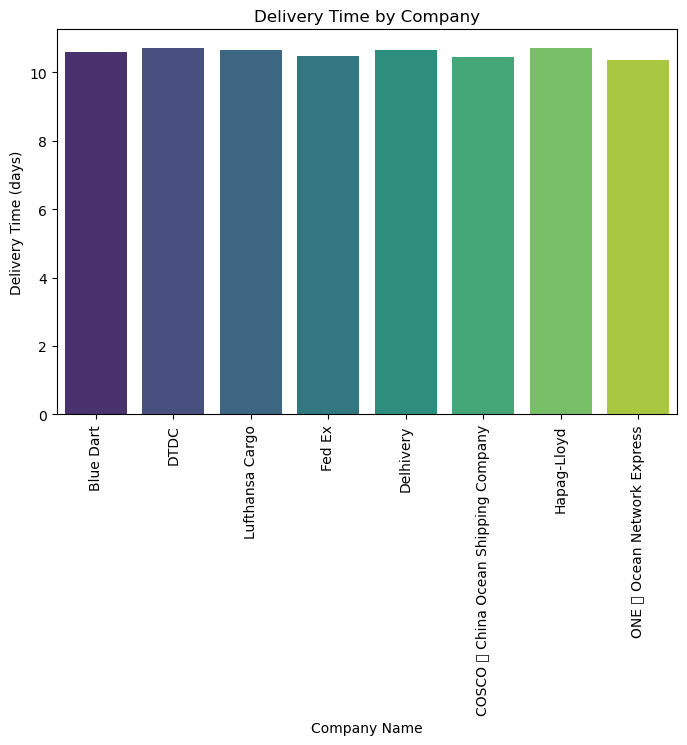

In [8]:
# Calculate delivery time correctly
merged["td"] = abs((merged["ShipDate"] - merged["DeliveryDate"]).dt.days)
# Create the barplot
plt.figure(figsize=(8, 5))
sns.barplot(x='CompanyName', y='td', data=merged, ci=None, palette='viridis')

# Formatting the plot
plt.title('Delivery Time by Company')
plt.xlabel('Company Name')
plt.ylabel('Delivery Time (days)')
plt.xticks(rotation=90)

plt.show()

In [9]:
sd=pd.merge(products,Order_d,on="ProductID")
sd.head(1)

,ProductID,Product,Category_ID,Sub_Category,Brand,Sale_Price,Market_Price,Type,Rating,OrderDetailID,OrderID,Quantity,SupplierID
0,1,Original Disinfectant Toilet Cleaner Liquid,5001,All Purpose Cleaners,Harpic,489,534,Toilet Cleaners,1,569,7655600,1,2


In [10]:
sd.shape

(27527, 13)

In [11]:
sd.dtypes

ProductID         int64
Product          object
Category_ID       int64
Sub_Category     object
Brand            object
Sale_Price        int64
Market_Price      int64
Type             object
Rating            int64
OrderDetailID     int64
OrderID           int64
Quantity          int64
SupplierID        int64
dtype: object

**most selling product**

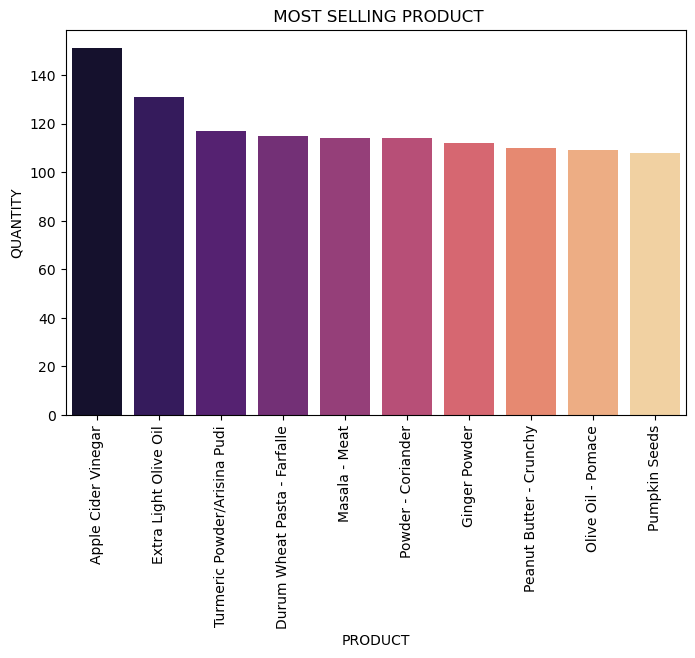

In [12]:
total_delivery = sd.groupby('Product')['Quantity'].sum().nlargest(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=total_delivery.index, y=total_delivery.values, palette='magma')
plt.title(' MOST SELLING PRODUCT')
plt.xlabel('PRODUCT')
plt.ylabel('QUANTITY')
plt.xticks(rotation=90)
plt.show()


In [13]:
sd['Market_Price'] = pd.to_numeric(sd['Market_Price'], errors='coerce')
sd['Sale_Price'] = pd.to_numeric(sd['Sale_Price'], errors='coerce')

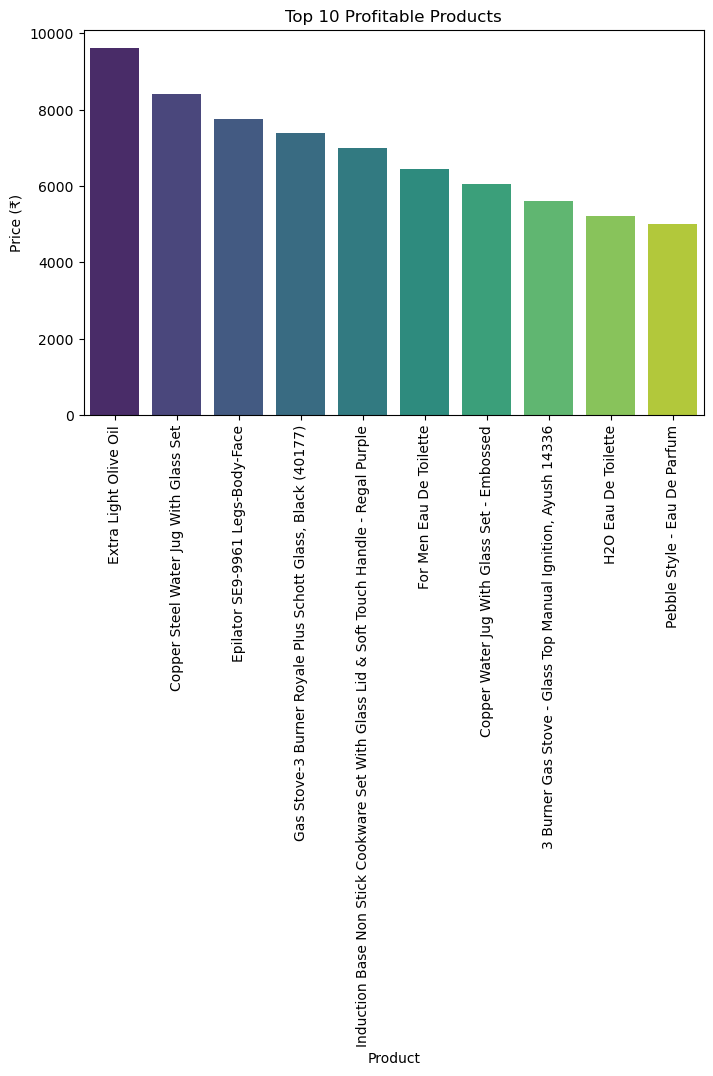

In [14]:
# Calculating Profit

sd['Total_profit'] = sd['Market_Price'] - sd['Sale_Price']
top_products = sd.groupby('Product')['Total_profit'].sum().nlargest(10).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='Product', y='Total_profit', data=top_products, ci=None, palette='viridis')
plt.title("Top 10 Profitable Products")
plt.xlabel("Product")
plt.ylabel("Price (₹)")
plt.xticks(rotation=90)  
plt.show()

In [15]:
prd=pd.read_csv("Products.csv")
prd.head()

,ProductID,Product,Category_ID,Sub_Category,Brand,Sale_Price,Market_Price,Type,Rating
0,1,Original Disinfectant Toilet Cleaner Liquid,5001,All Purpose Cleaners,Harpic,489,534,Toilet Cleaners,1
1,2,Surface Disinfectant Spray,5001,All Purpose Cleaners,Savlon,257,318,Disinfectant Spray & Cleaners,5
2,3,Harpic Disinfectant Toilet Cleaner Original200...,5001,All Purpose Cleaners,bb Combo,74,76,Toilet Cleaners,3
3,4,Harpic Toilet Cleaner Liquid - Original 1 L + ...,5001,All Purpose Cleaners,bb Combo,462,558,Toilet Cleaners,3
4,5,Disinfectant Bathroom Cleaner Liquid - Lemon,5001,All Purpose Cleaners,Harpic,299,362,Toilet Cleaners,2


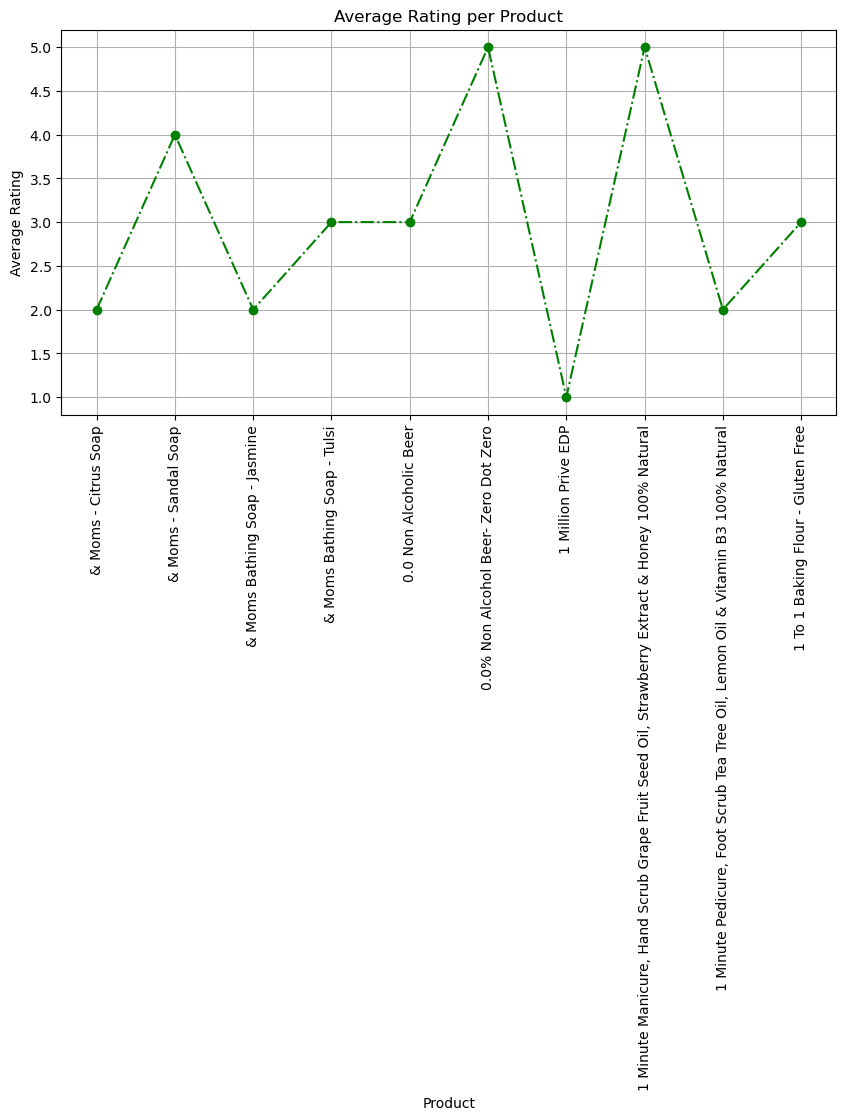

In [16]:
import matplotlib.pyplot as plt

# Group and calculate mean rating per product
rating = prd.groupby("Product")["Rating"].mean().head(10)

# Plot correctly using index
plt.figure(figsize=(10, 5))
plt.plot(rating.index, rating.values, marker='o', linestyle='-.', color='g')

# Formatting
plt.title('Average Rating per Product')
plt.grid()
plt.xlabel('Product')
plt.ylabel('Average Rating')
plt.xticks(rotation=90)

plt.show()

In [17]:
prd.head()

,ProductID,Product,Category_ID,Sub_Category,Brand,Sale_Price,Market_Price,Type,Rating
0,1,Original Disinfectant Toilet Cleaner Liquid,5001,All Purpose Cleaners,Harpic,489,534,Toilet Cleaners,1
1,2,Surface Disinfectant Spray,5001,All Purpose Cleaners,Savlon,257,318,Disinfectant Spray & Cleaners,5
2,3,Harpic Disinfectant Toilet Cleaner Original200...,5001,All Purpose Cleaners,bb Combo,74,76,Toilet Cleaners,3
3,4,Harpic Toilet Cleaner Liquid - Original 1 L + ...,5001,All Purpose Cleaners,bb Combo,462,558,Toilet Cleaners,3
4,5,Disinfectant Bathroom Cleaner Liquid - Lemon,5001,All Purpose Cleaners,Harpic,299,362,Toilet Cleaners,2


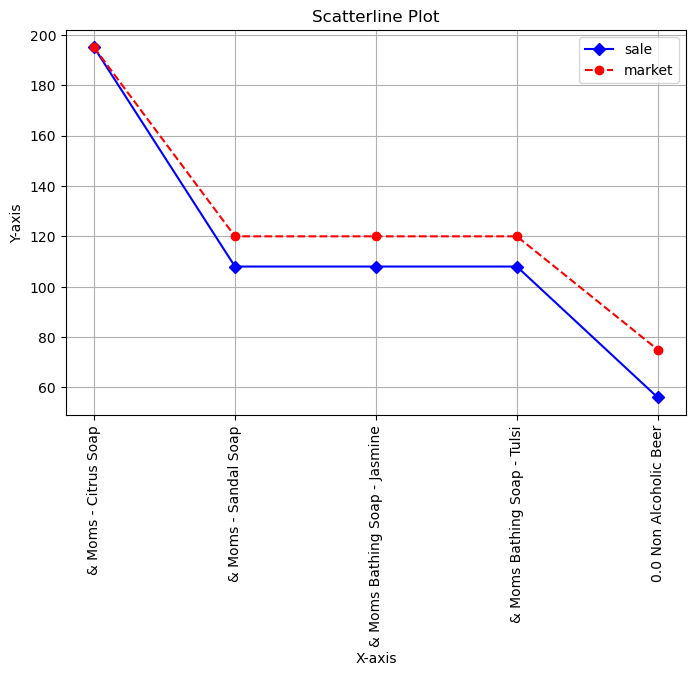

In [18]:
sale=prd.groupby("Product")["Sale_Price"].sum().head()
market=prd.groupby("Product")["Market_Price"].sum().head()

plt.figure(figsize=(8, 5))

# plt.scatter(sale.index, sale.values, color='blue', label=' Sale Price', marker='o')
plt.plot(sale.index, sale.values, linestyle='-',label="sale",marker="D" ,color='blue')

# plt.scatter(market.index, market.values, color='red', label=' Market Price', marker='s')
plt.plot(market.index, market.values, linestyle='--',label="market",marker="o", color='red')

plt.title('Scatterline Plot')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True)
plt.xticks(rotation=90)


plt.show()





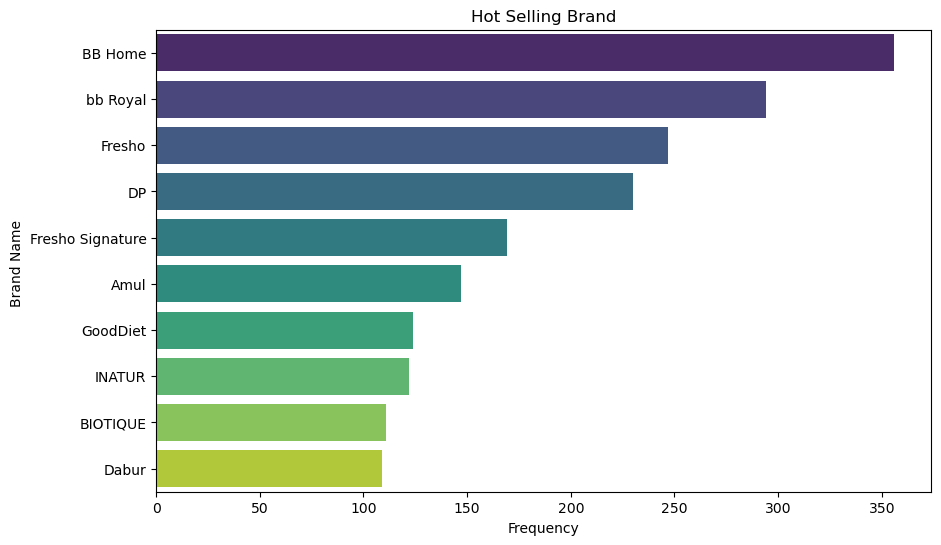

In [19]:
brand=prd["Brand"].value_counts().nlargest(10)
# plt.barh(brand.index,brand.values)
plt.figure(figsize=(10, 6))
sns.barplot(x=brand.values, y=brand.index, palette="viridis")



plt.xlabel("Frequency")
plt.ylabel("Brand Name ")
plt.title("Hot Selling Brand")
plt.show()


In [20]:
ship_order=pd.merge(shippers,order,on="ShipperID")
ship_order.head()

,ShipperID,CompanyName,Phone,OrderID,CustomerID,PaymentID,OrderDate,ShipDate,DeliveryDate,Total_order_amount
0,1,Blue Dart,9273377892,7655503,57088,4,09-02-2020,13-02-2020,26-02-2020,16063.0
1,1,Blue Dart,9273377892,7655505,57094,4,15-02-2020,24-02-2020,27-02-2020,13581.0
2,1,Blue Dart,9273377892,7655519,57121,4,15-03-2020,21-03-2020,26-03-2020,2555.0
3,1,Blue Dart,9273377892,7655520,57083,5,18-03-2020,19-03-2020,06-04-2020,14685.0
4,1,Blue Dart,9273377892,7655530,57091,5,02-04-2020,12-04-2020,15-04-2020,12918.0


In [21]:
ship_order.dtypes

ShipperID               int64
CompanyName            object
Phone                   int64
OrderID                 int64
CustomerID              int64
PaymentID               int64
OrderDate              object
ShipDate               object
DeliveryDate           object
Total_order_amount    float64
dtype: object

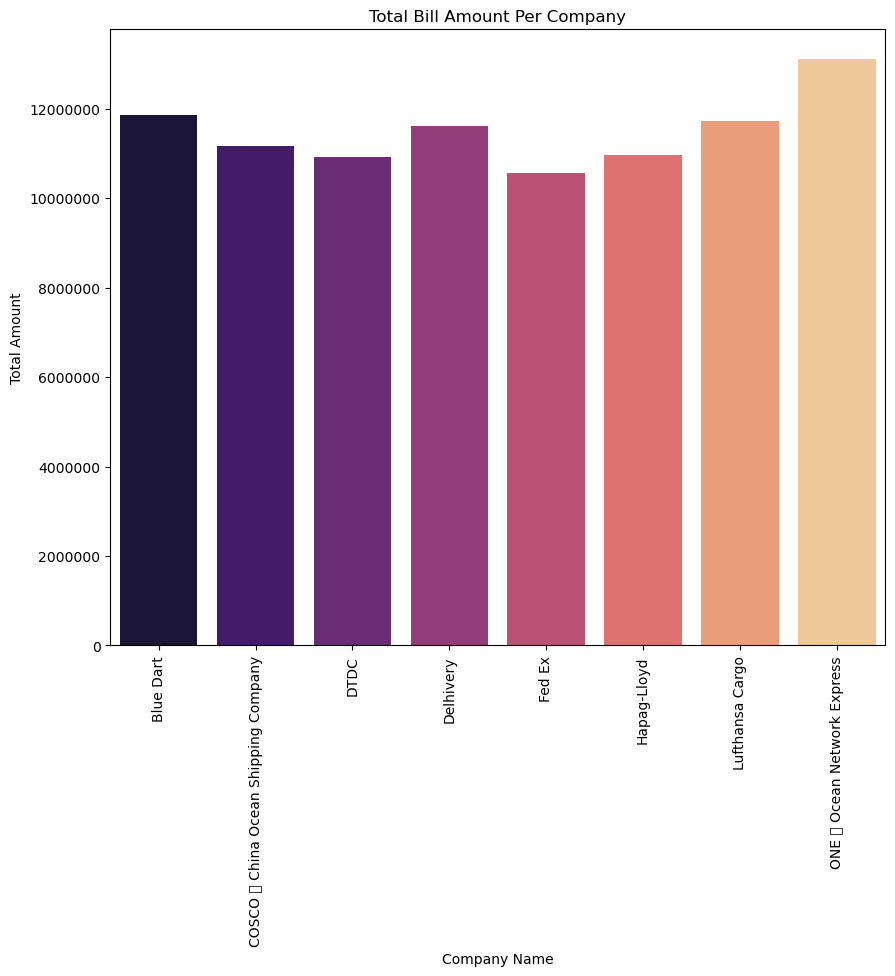

In [22]:
bill=ship_order.groupby("CompanyName")["Total_order_amount"].sum().head(10)
plt.figure(figsize=[10,8])
sns.barplot(x=bill.index,y=bill.values,palette="magma")
plt.xlabel("Company Name")
plt.ylabel("Total Amount")
plt.title("Total Bill Amount Per Company")
plt.xticks(rotation=90)
plt.ticklabel_format(style='plain', axis='y')

plt.show()



In [23]:
selling_state=pd.merge(suppliers,Order_d,on="SupplierID")
selling_state.head()

,SupplierID,CompanyName,City,State,PostalCode,Country,Phone,Email,OrderDetailID,OrderID,ProductID,Quantity
0,1,Sunshine Electronics Pvt. Ltd.,Fremont,California,841726,USA,8796300412,contactus@sunelec.com,8,7655500,8703,14
1,1,Sunshine Electronics Pvt. Ltd.,Fremont,California,841726,USA,8796300412,contactus@sunelec.com,10,7655501,13301,19
2,1,Sunshine Electronics Pvt. Ltd.,Fremont,California,841726,USA,8796300412,contactus@sunelec.com,12,7655501,17087,9
3,1,Sunshine Electronics Pvt. Ltd.,Fremont,California,841726,USA,8796300412,contactus@sunelec.com,27,7655503,17363,16
4,1,Sunshine Electronics Pvt. Ltd.,Fremont,California,841726,USA,8796300412,contactus@sunelec.com,32,7655504,10148,20


In [24]:
selling_state.isnull().sum()

SupplierID       0
CompanyName      0
City             0
State            0
PostalCode       0
Country          0
Phone            0
Email            0
OrderDetailID    0
OrderID          0
ProductID        0
Quantity         0
dtype: int64

In [25]:
selling_state["State"].unique()

array(['California', 'Abu Dhabhi', 'Texas', 'Karnataka', 'West Bengal',
       'New York'], dtype=object)

In [26]:
selling_state["Country"].unique()

array(['USA', 'UAE', 'India'], dtype=object)

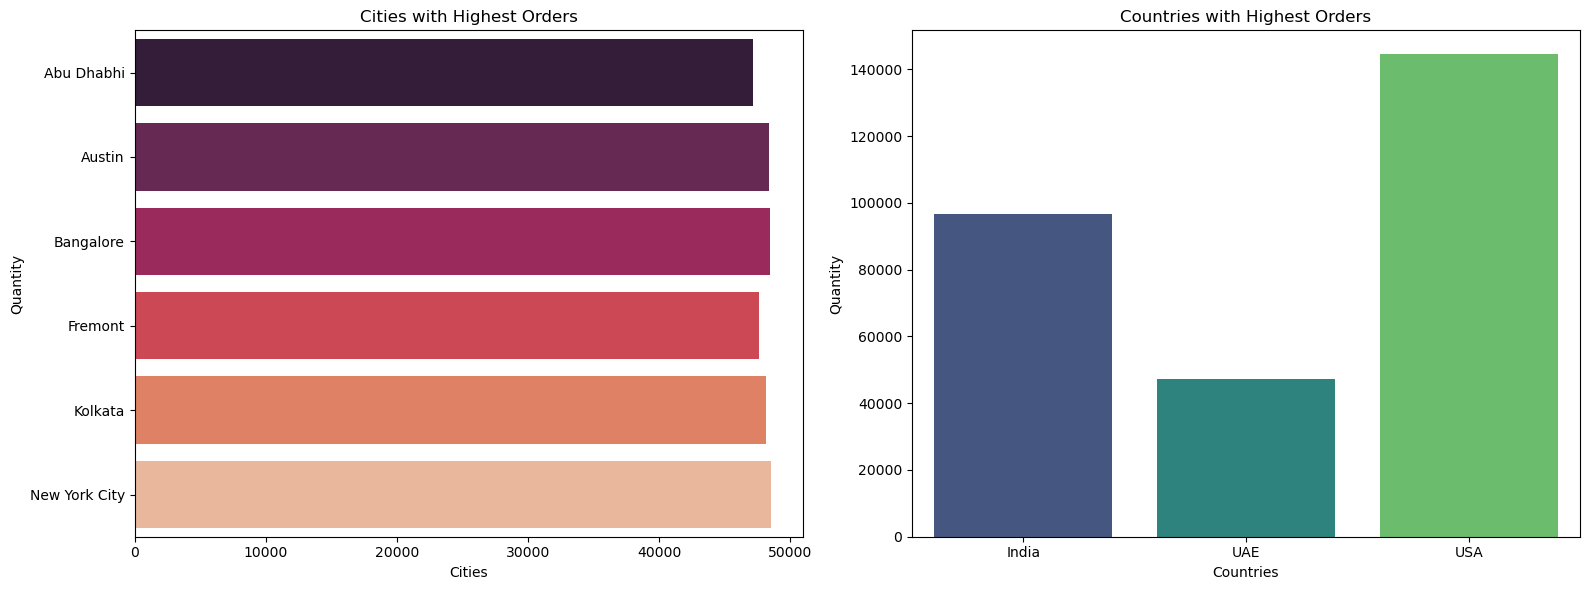

In [27]:
top_cities=selling_state.groupby("City")["Quantity"].sum()
top_country=selling_state.groupby("Country")["Quantity"].sum()

plt.figure(figsize=(16,6))
# Subplot 1: Topmost  cities with highest orders
plt.subplot(1,2,1)
sns.barplot(x=top_cities.values,y=top_cities.index,palette="rocket")
plt.title("Cities with Highest Orders")
plt.xlabel("Cities")
plt.ylabel("Quantity")

# Subplot 2: Topmost countries with highest orders

plt.subplot(1,2,2)
sns.barplot(x=top_country.index,y=top_country.values,palette="viridis")
plt.title("Countries with Highest Orders")
plt.xlabel("Countries")
plt.ylabel("Quantity")

plt.tight_layout()
plt.show()

In [28]:
order_payment=pd.merge(order,payments,on="PaymentID")
order_payment.head()

,OrderID,CustomerID,PaymentID,OrderDate,ShipperID,ShipDate,DeliveryDate,Total_order_amount,PaymentType,Allowed
0,7655500,57083,2,12-01-2020,7,13-01-2020,19-01-2020,25112.0,POD,Yes
1,7655501,57086,3,20-01-2020,2,24-01-2020,27-01-2020,22453.0,PayPal,Yes
2,7655502,57086,4,06-02-2020,7,11-02-2020,21-02-2020,13293.0,Credit Card,Yes
3,7655503,57088,4,09-02-2020,1,13-02-2020,26-02-2020,16063.0,Credit Card,Yes
4,7655504,57090,4,11-02-2020,3,15-02-2020,20-02-2020,15193.0,Credit Card,Yes


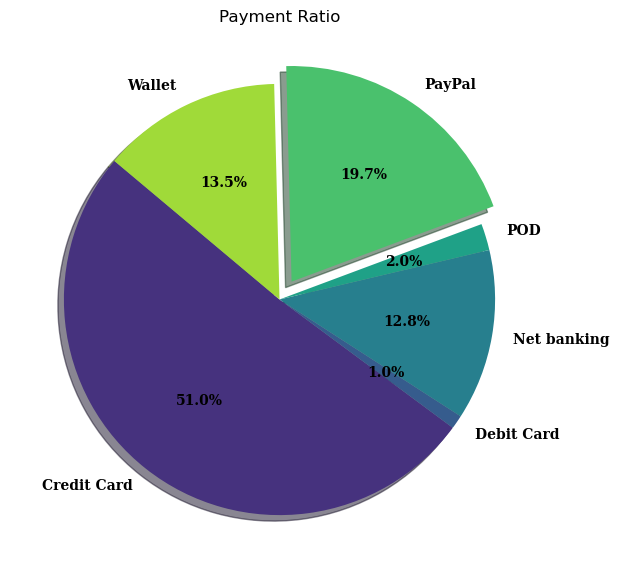

In [29]:
total_payment_by_type=order_payment.groupby("PaymentType")["Total_order_amount"].sum()
colors = sns.color_palette("viridis", len(total_payment_by_type))  
# Create pie chart with dynamic colors
plt.figure(figsize=(7,7))
explode_values = [0.1 if label == "PayPal" else 0 for label in total_payment_by_type.index]
plt.pie(total_payment_by_type.values, labels=total_payment_by_type.index, autopct='%1.1f%%', startangle=140, explode=explode_values, shadow=True,
        colors=colors,textprops={'fontsize': 10, 'fontweight': 'bold', 'fontfamily': 'serif'})
plt.title("Payment Ratio")
plt.show()


In [30]:
suppliers.head()

,SupplierID,CompanyName,City,State,PostalCode,Country,Phone,Email
0,1,Sunshine Electronics Pvt. Ltd.,Fremont,California,841726,USA,8796300412,contactus@sunelec.com
1,2,Tasha Apparel,Abu Dhabhi,Abu Dhabhi,683008,UAE,8773744676,customercare@tashaapparel.com
2,3,Alpha imports,Austin,Texas,889037,USA,9872259654,customers@alphaimports.com
3,4,GreenDroShip,Bangalore,Karnataka,416556,India,8245273210,gogreen@greendrop.co.in
4,5,Megagoods,Kolkata,West Bengal,119658,India,8568274416,gobig@megagoods.co.in


In [31]:
customer.head()

,CustomerID,FirstName,LastName,City,State,Country,PostalCode,Phone,Email,DateEntered
0,57081,James,Smith,New York,New York,United States,280862,9638483934,James.Smith@gmail.com,2020-01-02
1,57082,Robert,Downey Jr,New York,New York,United States,376573,6588282115,Robert.Downey Jr@gmail.com,2020-01-06
2,57083,John,Williams,Chicago,Illinois,United States,485629,7641021429,John.Williams@gmail.com,2020-01-11
3,57084,Michael,Johnson,Brisbane,Queensland,Australia,260866,7354232181,Michael.Johnson@gmail.com,2020-01-16
4,57085,Steve,Williams,Bremen,Bremen,Germany,740338,6285552036,Steve.Williams@gmail.com,2020-01-17


In [32]:
# Correct way to filter rows where "Country" is "India"
filtered_customers = customer[customer["Country"] == "India"]

# Print states for the filtered rows
print(filtered_customers["State"].unique())
print(filtered_customers["City"].unique())



['Haryana' 'Uttar Pradesh' 'Punjab' 'Madhya Pradesh' 'Rajasthan'
 'Maharashtra' 'West Bengal' 'Tamil Nadu' 'Karnataka' 'Gujarat'
 'Telangana' 'Delhi']
['Gurgaon' 'Varanasi' 'Amritsar' 'Faridabad' 'Ghaziabad' 'Agra' 'Bhopal'
 'Lucknow' 'Kanpur' 'Jaipur' 'Pune' 'Kolkata' 'Chennai' 'Bangalore'
 'Ahmedabad' 'Hyderabad' 'Delhi' 'Mumbai']


In [33]:
# Filter dataset for rows where "Country" is "India"
indian_df = customer[customer["Country"] == "India"][["City", "State"]].reset_index(drop=True)

# Display the new DataFrame
indian_df.head()

,City,State
0,Gurgaon,Haryana
1,Gurgaon,Haryana
2,Varanasi,Uttar Pradesh
3,Gurgaon,Haryana
4,Amritsar,Punjab


In [34]:
indian_df["City"].unique()

array(['Gurgaon', 'Varanasi', 'Amritsar', 'Faridabad', 'Ghaziabad',
       'Agra', 'Bhopal', 'Lucknow', 'Kanpur', 'Jaipur', 'Pune', 'Kolkata',
       'Chennai', 'Bangalore', 'Ahmedabad', 'Hyderabad', 'Delhi',
       'Mumbai'], dtype=object)

In [35]:
indian_df["State"].unique()

array(['Haryana', 'Uttar Pradesh', 'Punjab', 'Madhya Pradesh',
       'Rajasthan', 'Maharashtra', 'West Bengal', 'Tamil Nadu',
       'Karnataka', 'Gujarat', 'Telangana', 'Delhi'], dtype=object)

In [36]:
pip install geopy

Note: you may need to restart the kernel to use updated packages.


In [37]:
from geopy.geocoders import Nominatim
import pandas as pd



# Initialize geocoder
# geolocator = Nominatim(user_agent="geoapiExercises")
geolocator = Nominatim(user_agent="my_geo_app")  # Custom user-agent

# Function to get coordinates
def get_coordinates(City, State):
    location = geolocator.geocode(f"{City}, {State}, India")
    return location.latitude if location else None, location.longitude if location else None

# Loop through rows and apply function
indian_df["latitude"], indian_df["longitude"] = zip(*[get_coordinates(City, State) for City, State in zip(indian_df["City"], indian_df["State"])])

# Display updated DataFrame
indian_df.head()

,City,State,latitude,longitude
0,Gurgaon,Haryana,28.464615,77.029919
1,Gurgaon,Haryana,28.464615,77.029919
2,Varanasi,Uttar Pradesh,25.335649,83.007629
3,Gurgaon,Haryana,28.464615,77.029919
4,Amritsar,Punjab,31.635666,74.878750


In [38]:
indian_df.shape

(40, 4)

In [39]:

city=folium.Map(location=(20.5937,78.9629),
             zoom_start=5,
             zoom_control=True)
for index,row in indian_df.iterrows():
    folium.Marker([row['latitude'],row['longitude']],
                  popup=row['City'],
                  tooltip="click me!",
                  icon=folium.Icon(color="red")).add_to(city)
# m.save("map.html")

city

In [40]:

state=folium.Map(location=(20.5937,78.9629),
             zoom_start=5,
             zoom_control=True)
for index,row in indian_df.iterrows():
    folium.Marker([row['latitude'],row['longitude']],
                  popup=row['State'],
                  tooltip="click me!",
                  icon=folium.Icon(color="red")).add_to(state)
# m.save("map.html")
state